<a href="https://colab.research.google.com/github/mupungijose-hue/Data-Analysis-Projects/blob/main/Exp3_Simulating_Multiple_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import  ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#Load datasets from Github
url = "https://raw.githubusercontent.com/amankharwal/Website-data/master/CarPrice.csv"
df = pd.read_csv(url)

print("\nDataset loaded Successfully!\n")


Dataset loaded Successfully!



In [ ]:
print("Avialable Clumns in Dataset:\n")
for col in df.columns:
      print("-",col)

Avialable Clumns in Dataset:

- car_ID
- symboling
- CarName
- fueltype
- aspiration
- doornumber
- carbody
- drivewheel
- enginelocation
- wheelbase
- carlength
- carwidth
- carheight
- curbweight
- enginetype
- cylindernumber
- enginesize
- fuelsystem
- boreratio
- stroke
- compressionratio
- horsepower
- peakrpm
- citympg
- highwaympg
- price


In [ ]:
dependent_variables = input("\nEnter Dependent variables(target):").strip()
independent_input = input(
    "Enter Independent VAriables (comma separated):"
)

independent_variables = [col.strip() for col in independent_input.split(',')]


Enter Dependent variables(target):price
Enter Independent VAriables (comma separated):carlength,carheight,wheelbase


In [ ]:
x = df[independent_variables]
y = df[dependent_variables]

In [ ]:
from pandas.core.arrays import categorical
#Detect feature Types  automatically
numerical_features = []
categorical_features = []

for col in independent_variables:
    if df[col].dtype =='object':
      categorical_features.append(col)
    else:
        numerical_features.append(col)

print("\nNumeriucal Features:",numerical_features)
print("\nCategorical Features:",categorical_features)


Numeriucal Features: ['carlength', 'carheight', 'wheelbase']

Categorical Features: []


In [ ]:
# Preprocessing (Encoding + Scaling)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(), categorical_features)
    ]
)

In [ ]:
# Create Pipeline

model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)


In [ ]:
#Train-Test Split

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42
)

In [ ]:
# Train the model
model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = model.predict(x_test)

In [ ]:
# Model Evaluation
print("\nModel Performance:\n........................................")
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("R-Squared score (R2):", r2_score(y_test, y_pred))


Model Performance:
........................................
Mean Squared Error: 33949268.347139515
R-Squared score (R2): 0.5699576995338025


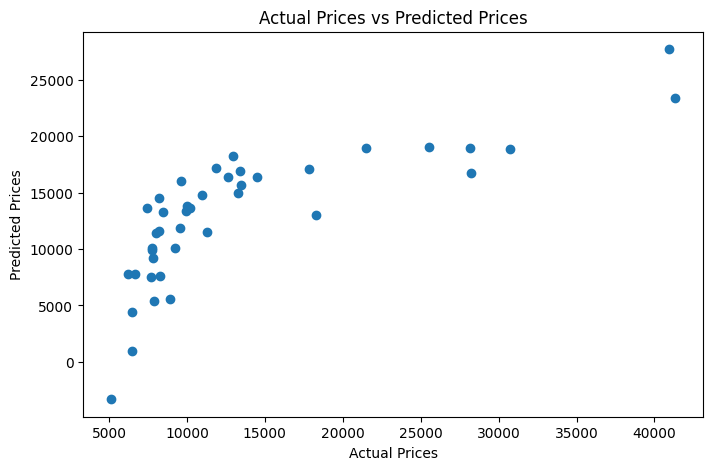

In [ ]:
# Visualization
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual Prices vs Predicted Prices")
plt.show()

In [ ]:
# Result Comparison Table
result = pd.DataFrame({
    'Actual Prices': y_test,
    'Predicted Prices': y_pred
})
display(result.head())

,Actual Prices,Predicted Prices
15,30760.000,18858.594987
9,17859.167,17095.079040
100,9549.000,11832.935376
132,11850.000,17205.843936
68,28248.000,16749.099301
